In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path
import json
import sys
import cv2

In [3]:
experiments_dir = Path("experiments")
losses_dir = Path("log")
quantitative_metrics = Path("visualization\quantitative_metrics.csv")
model_name = "cyclegan_checkpoint.pth"

In [4]:
def collect_losses(log_dir):
    collect_metric_history = []
    for history_file in log_dir.iterdir():
        history_file_name = history_file.name
        if history_file_name.endswith(".json") and history_file_name.startswith("Training_log"):
            with open(history_file,"r") as f:
                data = json.load(f)
                collect_metric_history.append(data)
                
    data = []
    for step in collect_metric_history:
        for train_it in step:
            row_temp = train_it["metrics"].copy()
            row_temp["epoch"] = train_it["epoch"]
            row_temp["it"] = train_it["iteration"]
            data.append(row_temp)
            
    df = pd.DataFrame(data)
    df = df.drop(columns="it")
    df = df.groupby('epoch').mean()
    return df


In [5]:
experiments_log = {
    "cyclegan_200":{"losses":None,"metrics":None},
    "cyclegan_CBAM_GL_V3_200_patch128_local5":{"losses":None,"metrics":None}
}

for experiment in experiments_dir.iterdir():
    if experiment.is_dir() and experiment.name in experiments_log.keys() :
        quantitative_metrics_file = experiment / quantitative_metrics
        if quantitative_metrics_file.exists():
            experiments_log[experiment.name]["metrics"] = pd.read_csv(quantitative_metrics_file)
        losses_dir_path = experiment / losses_dir
        if losses_dir_path.exists():
            experiments_log[experiment.name]["losses"] = collect_losses(losses_dir_path)

In [6]:
map_name = {
    "cyclegan_200" : "CycleGAN",
    "cyclegan_CBAM_GL_V3_200_patch128_local5" : "Our CycleGAN"
}

for old_name, new_name in map_name.items():
    experiments_log[new_name] = experiments_log.pop(old_name)

In [7]:
metrics = []
for model in experiments_log:
    serie = experiments_log[model]["metrics"].mean()
    serie.name = model
    metrics.append(serie)
df_metric = pd.DataFrame(metrics)
df_metric = df_metric.round(2)
df_metric

,PSNR,SSIM,LPIPS,NIQE
CycleGAN,23.56,0.78,0.19,5.09
Our CycleGAN,28.26,0.84,0.12,4.94


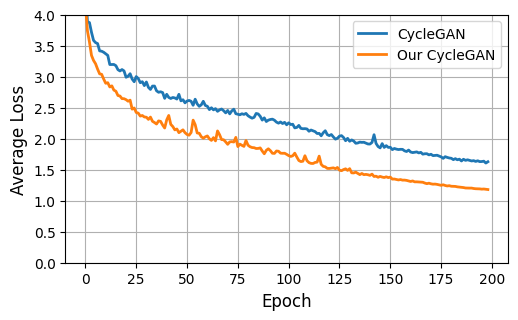

In [21]:
# experiments_log["CycleGAN"]["losses"]
fig = plt.figure(figsize=(5.28,3.31))
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Average Loss", fontsize=12)
plt.ylim(0, 4)
for model in experiments_log:
    df_losses = experiments_log[model]["losses"]
    plt.plot(df_losses["G_Total"], label = model, linewidth = 2)

plt.grid(linestyle = "-")
plt.legend()
plt.tight_layout()
plt.savefig("Loss-flow.svg", dpi=600)

In [9]:
from CycleGAN_arch import CycleGAN_CBAM_GL_V3, CycleGAN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_our_path = Path(r"models\cyclegan_CBAM_GL_V3_200_patch128_local5_model.pth")

model_our = CycleGAN_CBAM_GL_V3(device, only_G_A2B=True)
model_our.model_init()

model_our.load_model(model_path=str(model_our_path))
model_our.eval()
model_our = model_our.G_A2B


model_cyclegam_path = Path(r"models\cyclegan_200_model.pth")

model_cyclegan = CycleGAN(device, only_G_A2B=True)
model_cyclegan.model_init()

model_cyclegan.load_model(model_path=str(model_cyclegam_path))
model_cyclegan.eval()
model_cyclegan = model_cyclegan.G_A2B

Loading model from models\cyclegan_CBAM_GL_V3_200_patch128_local5_model.pth...
Model loaded successfully.
Loading model from models\cyclegan_200_model.pth...
Model loaded successfully.


In [10]:
from custom_dataset import CustomDataset_CBAM_GL_V2
from torch.utils.data import DataLoader
resize_to = 286 
crop_size = 256
cyclegan_transforms = transforms.Compose([
    transforms.Resize(resize_to, Image.BICUBIC),
    transforms.CenterCrop(crop_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

def denormalize_image_tensor(image_tensor):
    """
    Denormalizes the tensor output (C, H, W) from [-1, 1] to [0, 1] and plots it.
    """
    image_tensor = image_tensor * 0.5 + 0.5
    image_tensor = image_tensor.clamp(0.0, 1.0)
    return image_tensor

CustomDataset_CBAM_GL_V2 = CustomDataset_CBAM_GL_V2.setup_dataset(cyclegan_transforms)

In [11]:
test_dataset_path = r"Dataset\LOL-v2\lolv2_paired_with_filename.csv"
df_test = pd.read_csv(test_dataset_path)
df_test["low_light_path"] = df_test["low_light_path"].str[13:]
df_test["normal_light_path"] = df_test["normal_light_path"].str[13:]
df_test = df_test[(df_test["data_type"] == "Real_captured") & (df_test["section"] == "Test")]
dataset = CustomDataset_CBAM_GL_V2(df_test, is_test=True)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
# np.random.seed(42)


[83, 53, 70, 45, 44, 39]


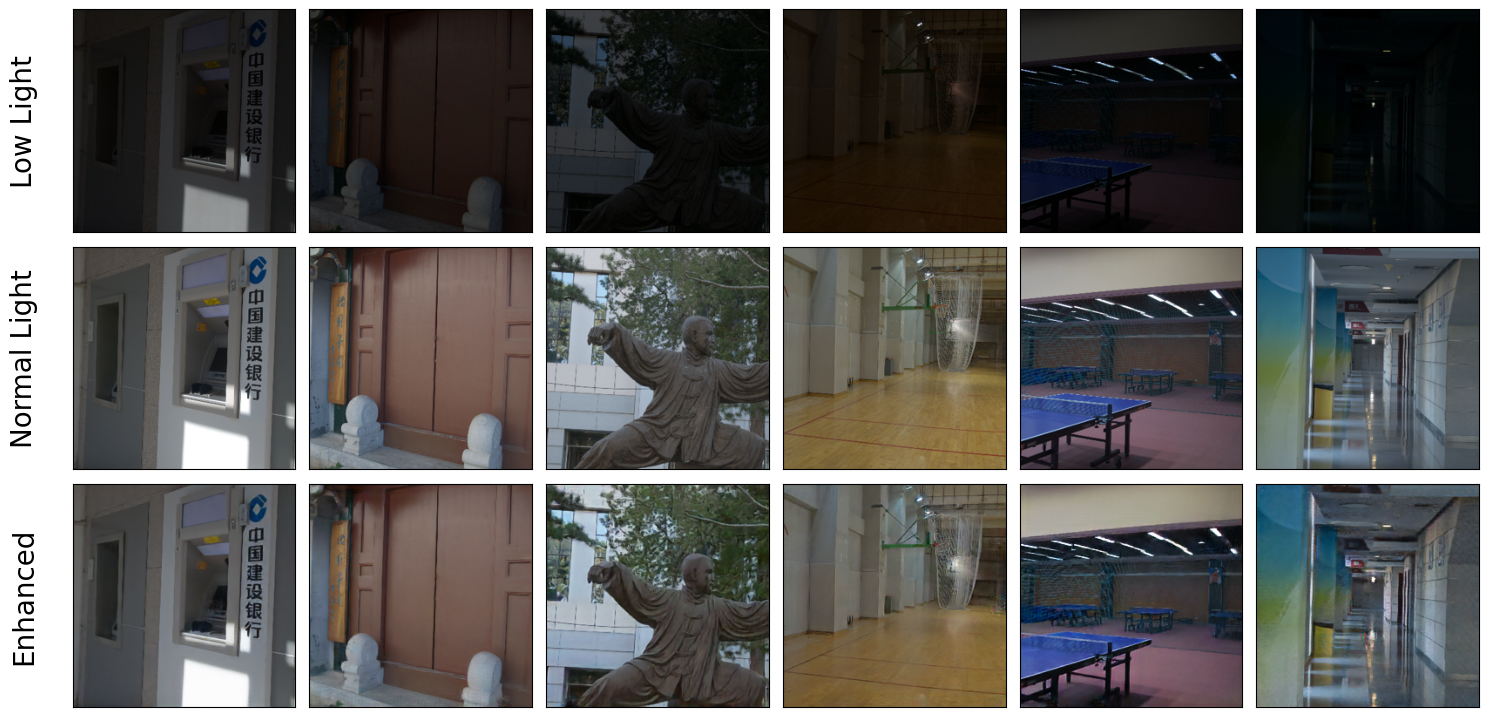

In [29]:
np.random.seed(42)
random_idx = np.random.choice(len(dataloader), 6, replace=False).tolist()
print(random_idx)

ylabels = ["Low Light", "Normal Light", "Enhanced"]

n_row = len(ylabels)
n_col = len(random_idx)
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 7.28), sharex=True, sharey=True)

fig.subplots_adjust(wspace=0.1, hspace=0.1)

count = 0
for i, (low_light_img, normal_light_img) in enumerate(dataloader):
    if i in random_idx:
        low_light_img = low_light_img.to(device)
        normal_light_img = normal_light_img.to(device)
        cyclegan_generated_img = model_cyclegan(low_light_img)
        our_generated_img = model_our(low_light_img)
        
        low_light_img = denormalize_image_tensor(low_light_img).cpu().detach()
        normal_light_img = denormalize_image_tensor(normal_light_img).cpu().detach()
        our_generated_img =  denormalize_image_tensor(our_generated_img).cpu().detach()
        
        low_light_img = low_light_img.squeeze().permute(1,2,0)
        normal_light_img = normal_light_img.squeeze().permute(1,2,0)
        our_generated_img = our_generated_img.squeeze().permute(1,2,0)
        
        
        
        image_list = [low_light_img, normal_light_img, our_generated_img]
        j=0
        for ax in axes[:,count]:
            axes[j,count].imshow(image_list[j])
            ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
            if count == 0:
                ax.set_ylabel(ylabels[j], fontsize=20, labelpad=25)
            j+=1
        
        count += 1
                
# fig.tight_layout()
plt.tight_layout()
plt.savefig("qualitative.svg", dpi=600)
    

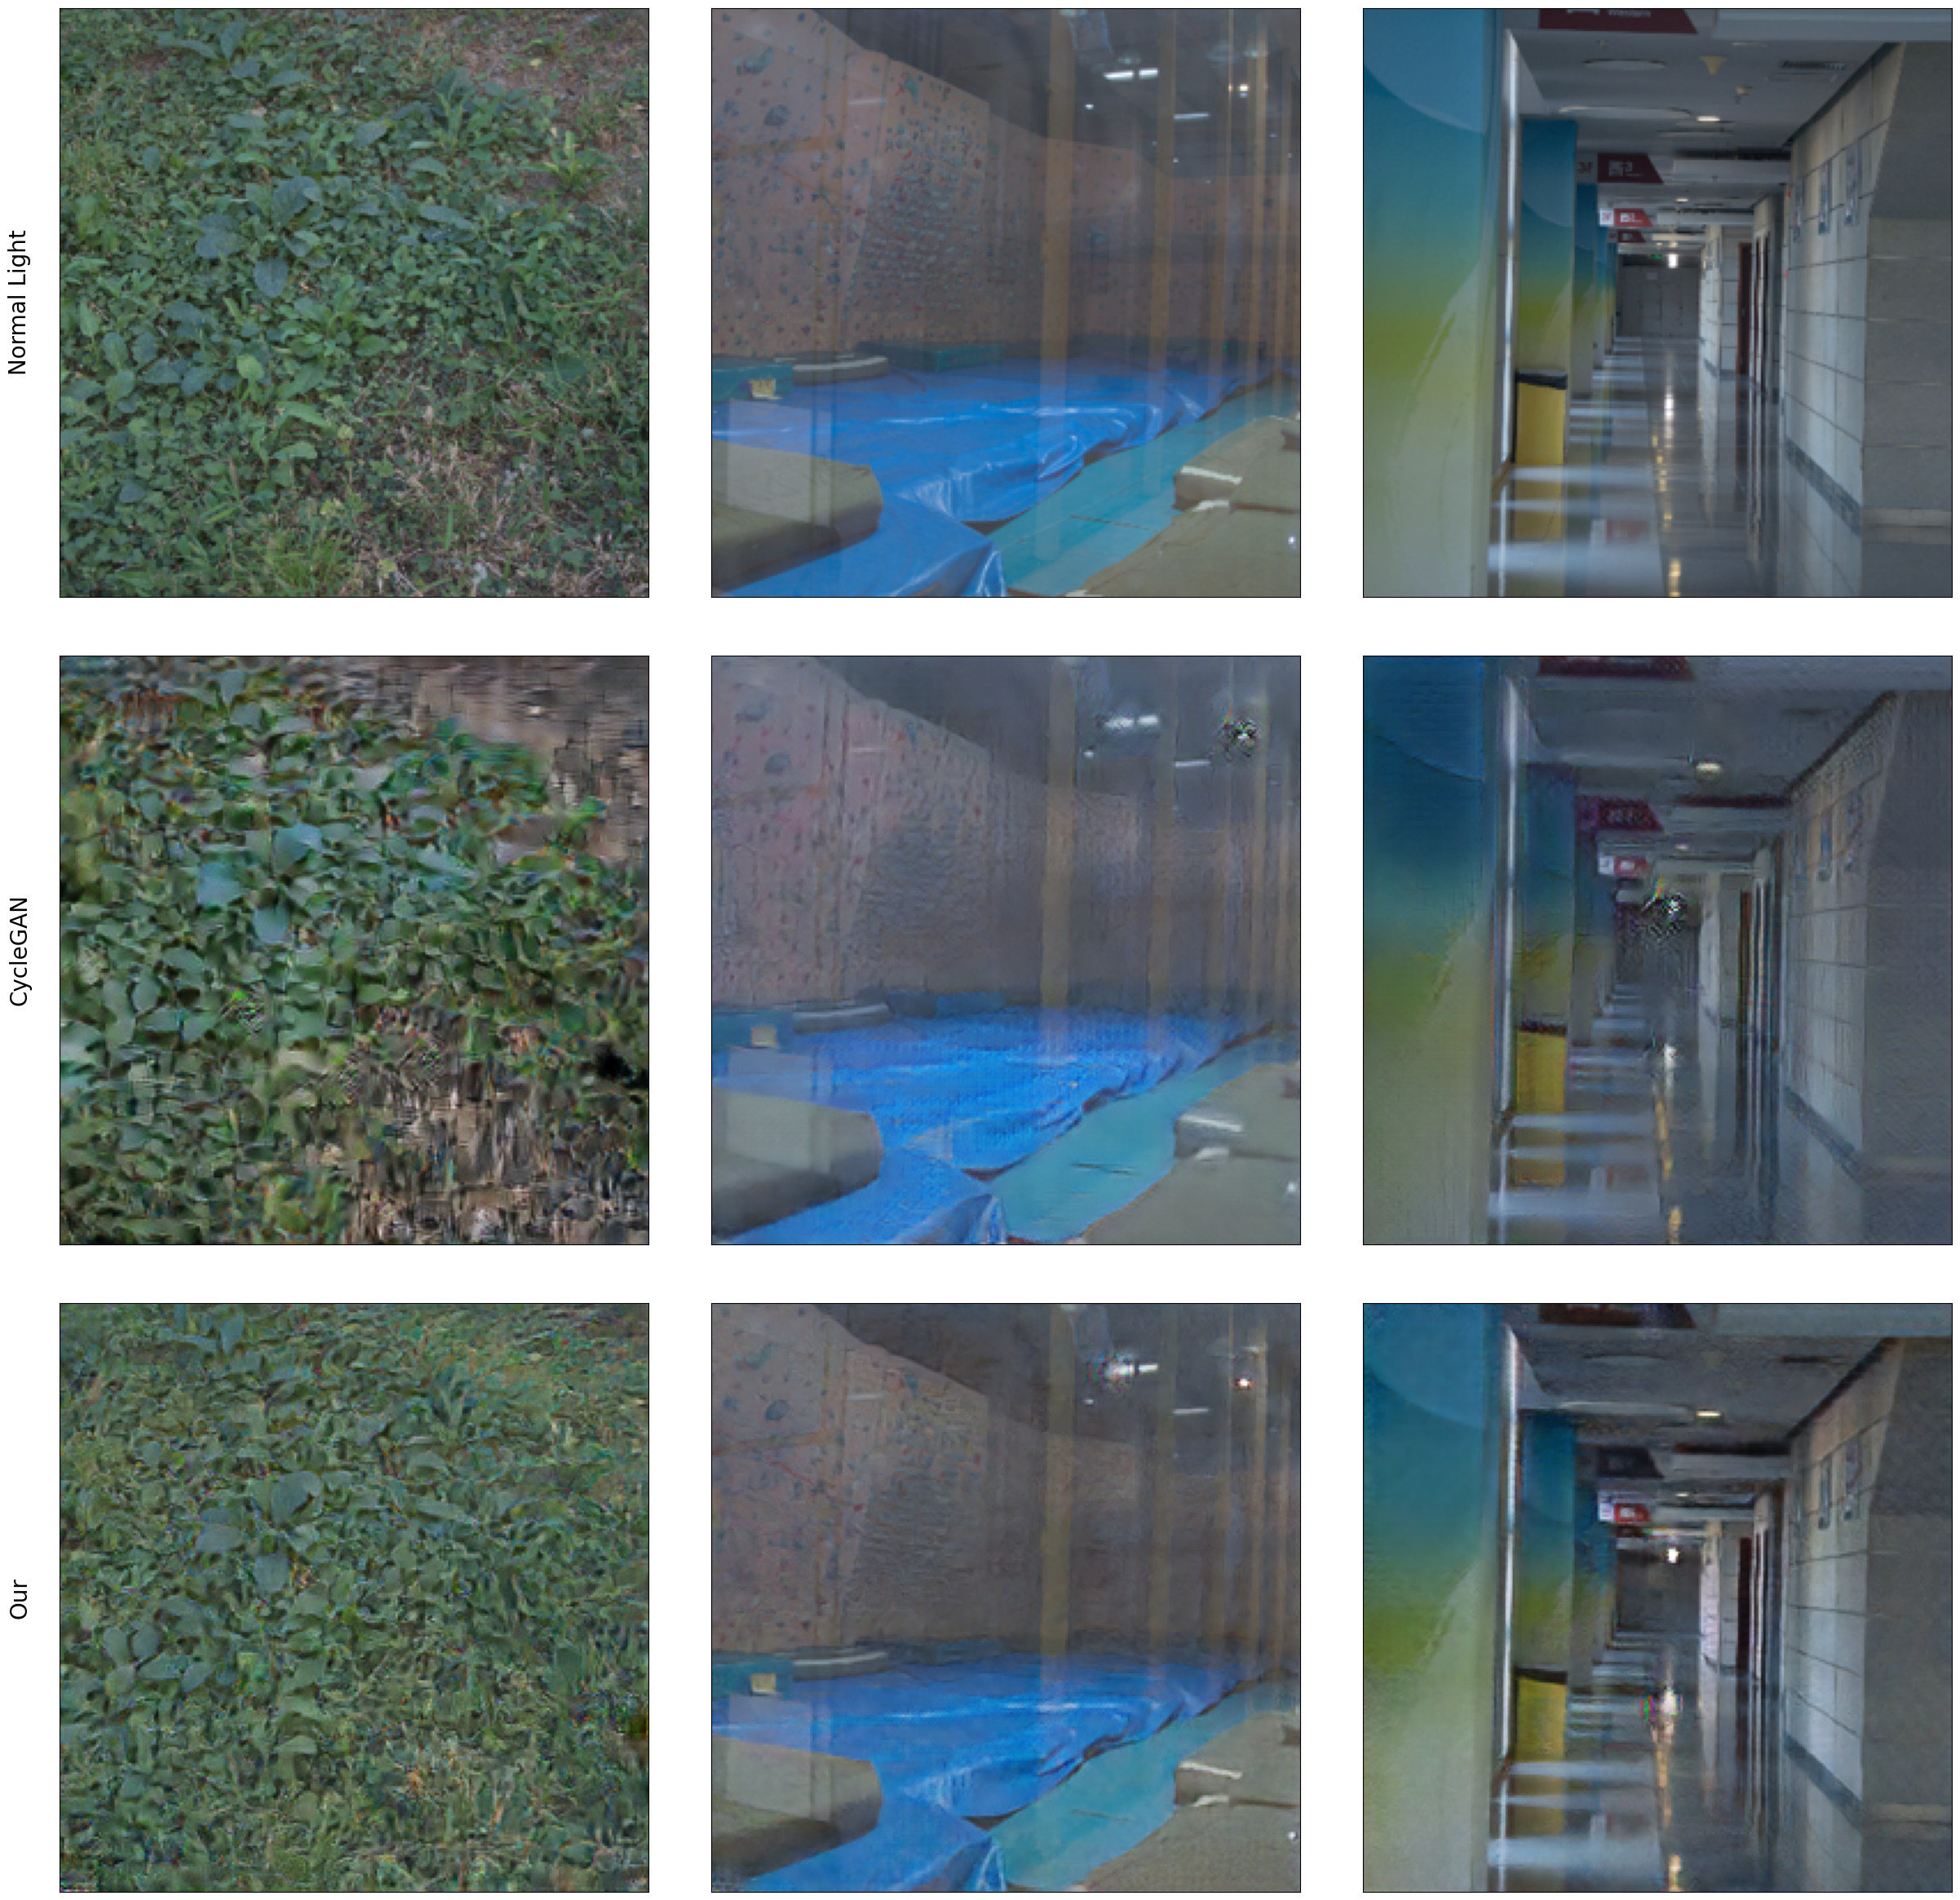

In [13]:
# random_idx = np.random.choice(len(dataloader), 6, replace=False).tolist()
# print(np.sort(random_idx))
random_idx = [37, 68, 83]
ylabels = ["Normal Light", "CycleGAN", "Our"]

n_row = len(ylabels)
n_col = len(random_idx)
fig, axes = plt.subplots(n_row, n_col, figsize=(n_col*10, n_row*10), sharex=True, sharey=True)

fig.subplots_adjust(wspace=0.1, hspace=0.1)

count = 0
for i, (low_light_img, normal_light_img) in enumerate(dataloader):
    if i in random_idx:
        low_light_img = low_light_img.to(device)
        normal_light_img = normal_light_img.to(device)
        cyclegan_generated_img = model_cyclegan(low_light_img)
        our_generated_img = model_our(low_light_img)
        
        low_light_img = denormalize_image_tensor(low_light_img).cpu().detach()
        normal_light_img = denormalize_image_tensor(normal_light_img).cpu().detach()
        cyclegan_generated_img =  denormalize_image_tensor(cyclegan_generated_img).cpu().detach()
        our_generated_img =  denormalize_image_tensor(our_generated_img).cpu().detach()
        
        low_light_img = low_light_img.squeeze().permute(1,2,0)
        normal_light_img = normal_light_img.squeeze().permute(1,2,0)
        cyclegan_generated_img = cyclegan_generated_img.squeeze().permute(1,2,0)
        our_generated_img = our_generated_img.squeeze().permute(1,2,0)
        
        
        
        image_list = [normal_light_img, cyclegan_generated_img, our_generated_img]
        j=0
        for ax in axes[:,count]:
            axes[j,count].imshow(image_list[j])
            ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
            if count == 0:
                ax.set_ylabel(ylabels[j], fontsize=20, labelpad=25)
            j+=1
        
        count += 1
                
# fig.tight_layout()
plt.show()
    

In [14]:
37, 68, 83

(37, 68, 83)